<a href="https://colab.research.google.com/github/op1154/MBA_Agents/blob/main/MBA__Agents_Multiagents_Aula4_LangGraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
# Instalar bibliotecas necessárias
!pip install -q -U langgraph langchain-openai

In [41]:
!pip install langchain_community

In [42]:
!pip show langgraph

Name: langgraph
Version: 1.2.12
Summary: Building stateful, multi-actor applications with LLMs
Home-page: https://docs.langchain.com/oss/python/langgraph/overview
Author: 
Author-email: 
License: 
Location: /usr/local/lib/python3.13/dist-packages
Requires: langchain-core, langgraph-checkpoint, langgraph-prebuilt, langgraph-sdk, pydantic, xxhash
Required-by: langchain


In [43]:
import os
# Permite usar os secrets
from google.colab import userdata
# Pegando a chave da OpenAI de forma segura
os.environ['OPENAI_API_KEY']=userdata.get('OPENAI_API_KEY')

In [65]:
# Projeto LangGraph
# Importações principais
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict

# Definição do estado global
class Estado(TypedDict):
    pergunta: str
    resposta: str

# Iniciando o modelo LLM
modelo = ChatOpenAI(model="gpt-5-nano")

# Nó 1: Recebe e exibe a pergunta
def no_receber_pergunta(state: Estado):
    print("🔹 Pergunta recebida:", state["pergunta"])
    return state

# Nó 2: Gera a resposta via LLM e salva no estado
def no_gerar_resposta(state: Estado):
    pergunta = state["pergunta"]
    resposta = modelo.invoke(pergunta) # Chamada ao LLM
    state["resposta"] = resposta.content
    print("🔹 Resposta gerada com sucesso.")
    return state

# Construindo o grafo
grafo = StateGraph(Estado)
grafo.add_node("receber_pergunta", no_receber_pergunta)
grafo.add_node("gerar_resposta", no_gerar_resposta)
grafo.add_edge("receber_pergunta", "gerar_resposta")
grafo.add_edge("gerar_resposta", END)

# Definindo início do fluxo
grafo.set_entry_point("receber_pergunta")

# Compila o grafo
app = grafo.compile()

In [66]:
def mock_llm(state: MessagesState):
    return {"messages": [{"role": "ai", "content": "hello world"}]}

graph = StateGraph(MessagesState)
graph.add_node(mock_llm)
graph.add_edge(START, "mock_llm")
graph.add_edge("mock_llm", END)
graph = graph.compile()

graph.invoke({"messages": [{"role": "user", "content": "hi!"}]})

{'messages': [HumanMessage(content='hi!', additional_kwargs={}, response_metadata={}, id='f2b96067-ba67-463d-a85e-b0c9ce01a8a2'),
  AIMessage(content='hello world', additional_kwargs={}, response_metadata={}, id='4c9c87e5-30d8-4e54-a4ca-ffae19971ed5', tool_calls=[], invalid_tool_calls=[])]}

## Langraph com o Tavily

In [46]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, List
import operator

import google.generativeai as genai
from langchain_google_genai import ChatGoogleGenerativeAI

from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage
from langchain_core.messages import BaseMessage

from langchain_community.tools.tavily_search import TavilySearchResults

In [47]:
!pip install langchain_tavily tavily-python

In [48]:
import os
from google.colab import userdata
from langchain_tavily import TavilySearch


OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')
TAVILY_API_KEY= userdata.get('TAVILY_API_KEY')

In [49]:
tool = TavilySearch(tavily_api_key=TAVILY_API_KEY, max_results=4)
print(type(tool))
print(tool.name)

<class 'langchain_tavily.tavily_search.TavilySearch'>
tavily_search


In [50]:
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

## Desenvolvento do Agente

In [55]:
class Agent:
    def __init__(self, model, tools, system=""):
        self.system = system
        graph = StateGraph(AgentState)
        graph.add_node("llm", self.call_LLM)
        graph.add_node("action", self.take_action)
        graph.add_conditional_edges(
            "llm",
            self.exists_action,
            {True: "action", False: END}
        )
        graph.add_edge("action", "llm")
        graph.set_entry_point("llm")
        self.graph = graph.compile()
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)



    def exists_action(self, state: AgentState):
        result = state['messages'][-1]
        return len(result.tool_calls) > 0



    def call_LLM(self, state: AgentState):
        messages = state['messages']
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages)
        return {'messages': [message]}



    def take_action(self, state: AgentState):
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"Calling: {t}")
            if not t['name'] in self.tools:
                print(f"\n bad tool name....")
                result = "bad tool name, retry"
            else:
                result = self.tools[t['name']].invoke(t['args'])
            results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
        print("Back to the model!")
        return {'messages': results}

In [56]:
prompt = """Você é um assistente de pesquisa inteligente. Use o mecanismo de busca para procurar informações. \
Você tem permissão para fazer múltiplas chamadas (seja em conjunto ou em sequência). \
Procure informações apenas quando tiver certeza do que você quer. \
Se precisar pesquisar alguma informação antes de fazer uma pergunta de acompanhamento, você tem permissão para fazer isso!
"""

In [53]:
model = ChatOpenAI(
    model="gpt-5-nano",
    temperature=0,
    api_key=OPENAI_API_KEY)

In [57]:
abot = Agent(model, [tool], system=prompt)

## O Mermaid fará o Grafo para visualizar

In [58]:
mermaid_code = abot.graph.get_graph().draw_mermaid()
print(mermaid_code)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	llm(llm)
	action(action)
	__end__([<p>__end__</p>]):::last
	__start__ --> llm;
	action --> llm;
	llm -. &nbsp;False&nbsp; .-> __end__;
	llm -. &nbsp;True&nbsp; .-> action;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



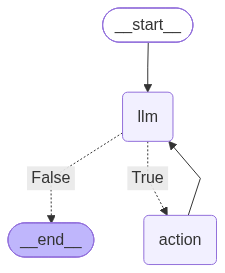

In [59]:
from IPython.display import Image, display

try:
    image_data = abot.graph.get_graph().draw_mermaid_png()
    display(Image(data=image_data))
except Exception as e:
    print(f"Erro ao tentar gerar PNG do Mermaid: {e}")
    print("\nCertifique-se de que a sua versão do LangGraph possui o método `.draw_mermaid_png()`.")
    print("Como alternativa, use `.draw_mermaid()` para obter a string e visualizar externamente.")

In [60]:
from langchain_community.tools.tavily_search import TavilySearchResults

In [61]:
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_openai import ChatOpenAI

prompt = """Você é um assistente de pesquisa inteligente. Use o mecanismo de busca para procurar informações. \
Você tem permissão para fazer múltiplas chamadas (seja em conjunto ou em sequência). \
Procure informações apenas quando tiver certeza do que você quer. \
Se precisar pesquisar alguma informação antes de fazer uma pergunta de acompanhamento, você tem permissão para fazer isso!
"""
model_instance = ChatOpenAI(model="gpt-5-nano", temperature=0, api_key=OPENAI_API_KEY)
tool_instance = TavilySearchResults(tavily_api_key=TAVILY_API_KEY, max_results=4)

abot = Agent(model_instance, [tool_instance], system=prompt)
messages = [HumanMessage(content="Como está o tempo em São Paulo hoje?")]

print("Iniciando interação do agente:")
final_result_state = None

for s in abot.graph.stream({"messages": messages}):
    print(s)
    print("---")
    final_result_state = s

print("\nResultado Final:")
if final_result_state and 'llm' in final_result_state and final_result_state['llm']['messages']:
    print(final_result_state['llm']['messages'][-1].content)
else:
    print("Nenhum resultado final ou resultado inesperado.")

Iniciando interação do agente:
{'llm': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 293, 'prompt_tokens': 242, 'total_tokens': 535, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 256, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-ERNPE6J3DyyZzx8MgBxqToHksBrJk', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0cfd9-866d-7e63-8745-dcc46bf6a6b6-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'tempo em S\x00e3o Paulo hoje'}, 'id': 'call_gOTTJGQsc87drZuyJlbc8jcU', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 242, 'output_tokens': 293, 'total_tokens': 535, 'input_t

## Verificando a previsão do tempo para amanhã

In [63]:
user_query_tomorrow = "Como estará o tempo em São Paulo amanhã dia 24/09/2026?" #atualizamos apenas a pergunta do usuário

messages_tomorrow = [HumanMessage(content=user_query_tomorrow)]

print("\n--- Iniciando interação do agente para amanhã ---")
final_result_state_tomorrow = None
for s in abot.graph.stream({"messages": messages_tomorrow}):
    print(s)
    print("---")
    final_result_state_tomorrow = s

print("\n--- Resultado Final para amanhã ---")
if final_result_state_tomorrow and 'llm' in final_result_state_tomorrow and final_result_state_tomorrow['llm']['messages']:
    print(final_result_state_tomorrow['llm']['messages'][-1].content)
else:
    print("Nenhum resultado final ou resultado inesperado para amanhã.")


--- Iniciando interação do agente para amanhã ---
{'llm': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 370, 'prompt_tokens': 250, 'total_tokens': 620, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 320, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-ERNPrXWPSlo7Rr1Mt1Lzn8aVPVseZ', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0cfda-2558-7aa0-ac5a-b3454a4c8b69-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'previs\x7fo do tempo S\x00e3o Paulo 24 de setembro de 2026'}, 'id': 'call_XGfT2zWcuGUpH2KDgGtCXkD2', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 250, '

In [21]:
messages = [HumanMessage(content="Como está o tempo em São Paulo e no Rio de Janeiro amanhã?")]
result = abot.graph.invoke({"messages": messages})
result

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'previsão do tempo amanhã São Paulo'}, 'id': 'call_hu9vgagsYCbt0wmoYuUvpr0m', 'type': 'tool_call'}
Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'previsão do tempo amanhã Rio de Janeiro'}, 'id': 'call_Ofn9uyLGgozl5reudlbJ4sRC', 'type': 'tool_call'}
Back to the model!


{'messages': [HumanMessage(content='Como está o tempo em São Paulo e no Rio de Janeiro amanhã?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 396, 'prompt_tokens': 247, 'total_tokens': 643, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 320, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-ERLV6qRKZKtTtnjSxNtfvjtfuqUKK', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0cf69-c6c3-70c0-8588-c3c4fd637a7f-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'previsão do tempo amanhã São Paulo'}, 'id': 'call_hu9vgagsYCbt0wmoYuUvpr0m', 'type': 'tool_call'}, {'name': 'tavil

In [22]:
result['messages'][-1].content

'Aqui vai a previsão rápida para amanhã:\n\n- São Paulo (SP)\n  - Temp: aproximadamente 16°C a 23°C.\n  - Tempo: sol entre nuvens, com pancadas de chuva no fim da manhã/tarde e chuva leve na noite.\n  - Dicas: roupas em camadas; leve guarda-chuva ou capa para o dia.\n\n- Rio de Janeiro (RJ)\n  - Temp: aproximadamente 17°C a 21°C.\n  - Tempo: dia chuvoso, com chuva ao longo do dia e possibilidade de chuva à noite.\n  - Dicas: leve guarda-chuva/capa; pode fazer frio pela manhã/à noite, então vista-se em camadas.\n\nSe quiser, posso buscar uma previsão específica de uma fonte (Climatempo, tempo.com, etc.) ou criar uma previsão hora a hora para cada cidade.'

## Fazendo uma requisição mais complexa

In [23]:
query_passado = "Qual país sediou a Copa do Mundo de futebol em 1998? Quem foi o campeão e qual o placar da final? \
Qual era o Produto Interno Bruto (PIB) desse país no ano da Copa e qual é o PIB atual (últimos dados disponíveis, como 2023 ou 2024) \
Qual a capital desse país e qual sua moeda atual? Responda a cada pergunta separadamente."
messages = [HumanMessage(content=query_passado)]

In [24]:
print("\nIniciando interação do agente para pergunta sobre o passado:")

current_state = {}
for s in abot.graph.stream({"messages": messages}):
    current_state.update(s)
    print(s)
    print("---")


print("\n--- Resultado Final para o Passado ---")
if 'llm' in current_state and 'messages' in current_state['llm'] and current_state['llm']['messages']:
    final_message_content = current_state['llm']['messages'][-1].content
    print(final_message_content)
else:
    print("Nenhum resultado final ou resultado inesperado. Verifique os logs acima.")


Iniciando interação do agente para pergunta sobre o passado:
{'llm': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 676, 'prompt_tokens': 319, 'total_tokens': 995, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 640, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-ERLVRyFCIAsVx9BTEnLdUoIxHTbr9', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0cf6a-1b74-71c0-97e3-7f9af6a64805-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'France GDP 1998 current US$ World Bank'}, 'id': 'call_uctP3XGVADuX4lOcbbHyxzbV', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 319, 'output_to

In [25]:
print("\n--- Agente de Pesquisa Interativo ---")
print("Digite sua pergunta ou 'sair' para encerrar.")

while True:
    user_input = input("\nVocê: ")
    if user_input.lower() == "sair":
        print("Agente: Encerrando a conversa. Até logo!")
        break

    messages = [HumanMessage(content=user_input)]

    print("Agente: Pensando e buscando...")
    final_result_state = None
    try:
        current_state = {}
        for s in abot.graph.stream({"messages": messages}):
            current_state.update(s)

        print("\nAgente:")
        if 'llm' in current_state and 'messages' in current_state['llm'] and current_state['llm']['messages']:
            final_message = current_state['llm']['messages'][-1]
            if hasattr(final_message, 'content'):
                print(final_message.content)
            else:
                print("Não foi possível extrair o conteúdo da resposta final do LLM.")
        else:
            print("Não foi possível obter uma resposta do agente para esta pergunta.")

    except Exception as e:
        print(f"Agente: Ocorreu um erro durante a execução: {e}")
        print("Tente novamente ou digite 'sair'.")

print("\n--- Conversa Encerrada ---")


--- Agente de Pesquisa Interativo ---
Digite sua pergunta ou 'sair' para encerrar.

Você: sair
Agente: Encerrando a conversa. Até logo!

--- Conversa Encerrada ---


### Persistência de memoria

In [33]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

# 1. O Estado: Define o que o grafo vai lembrar
class State(TypedDict):
    user_name: str

# 2. O Nó: Uma função simples que apenas salva o nome recebido
def save_name_node(state: State):
    return {"user_name": state.get("user_name", "Desconhecido")}

# 3. O Grafo: Cria a estrutura e adiciona a persistência (checkpointer)
checkpointer = InMemorySaver()

builder = StateGraph(State)
builder.add_node("agent", save_name_node)
builder.add_edge(START, "agent")
builder.add_edge("agent", END)

# Compilamos o grafo passando o guardador de memória
graph = builder.compile(checkpointer=checkpointer)

# --- DEMONSTRAÇÃO DA PERSISTÊNCIA ---

# Cenário A: Usando a Thread 1 (O agente vai lembrar)
config_1 = {"configurable": {"thread_id": "usuario_joao"}}

print("Turno 1 (Thread 1): Dizendo o nome")
state_1 = graph.invoke({"user_name": "João"}, config_1)
print(f"Memória atual da Thread 1: {state_1['user_name']}\n")

print("Turno 2 (Thread 1): Enviando dados vazios, mas na mesma thread")
state_2 = graph.invoke({}, config_1)
print(f"Memória recuperada da Thread 1: {state_2['user_name']}\n")


# Cenário B: Usando a Thread 2 (Nova conversa, memória limpa)
config_2 = {"configurable": {"thread_id": "usuario_anonimo"}}

print("Turno 3 (Thread 2): Perguntando o nome em uma nova thread")
state_3 = graph.invoke({}, config_2)
print(f"Memória da Thread 2: {state_3.get('user_name', 'Nada gravado')}")



Turno 1 (Thread 1): Dizendo o nome
Memória atual da Thread 1: João

Turno 2 (Thread 1): Enviando dados vazios, mas na mesma thread
Memória recuperada da Thread 1: João

Turno 3 (Thread 2): Perguntando o nome em uma nova thread
Memória da Thread 2: Desconhecido


In [28]:
#Thread ID muito longas pode resultar em Database error, enão ua solucao é trazer o UUID com limitador de caracteres
import uuid
Numero_thread = str(uuid.uuid4())[:255]
print(Numero_thread)
config = {"configurable": {"thread_id": Numero_thread}}

f3f0e6f6-3eee-4f43-b9eb-3b9a3d873a73


## Implementando a função reduceMessages

In [35]:
import os
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, List, Any, Dict
import operator
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage, AIMessage, BaseMessage
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_tavily import TavilySearch
from langchain_openai import ChatOpenAI
from dataclasses import dataclass, field

In [37]:
from google.colab import userdata

OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')
TAVILY_API_KEY = userdata.get('TAVILY_API_KEY')

In [38]:
from uuid import uuid4

def reduce_messages(left: list[AnyMessage], right: list[AnyMessage]) -> list[AnyMessage]:

    for message in right:
        if not message.id:
            message.id = str(uuid4())

    merged = left.copy()
    for message in right:
        for i, existing in enumerate(merged):

            if existing.id == message.id:
                merged[i] = message
                break
        else:
            merged.append(message)
    return merged

In [39]:
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], reduce_messages]